<a href="https://colab.research.google.com/github/smaran19/Employee-Attrition-Prediction-using-XGBoost/blob/main/employee_attrition_prediction_using_xgboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Employee Attrition Prediction using XGBoost

## Problem Statement
The objective of this project is to predict whether an employee is likely to leave the organization based on demographic and work-related features.  
Early identification of high-risk employees enables HR teams to take preventive actions and reduce attrition-related costs.

This notebook documents the complete model development process, starting from a baseline model and progressively improving it to a final calibrated XGBoost model.


## Dataset Source


The dataset used in this notebook was obtained from Kaggle:

- Dataset: Employee dataset  
- Author: Tawfik Elmetwally  

The file was renamed locally for convenience during development.



## Dataset Overview

- Total records:4653 Rows
- Features: Education, JoiningYear, City, PaymentTier, Age, Gender, EverBenched, ExperienceInCurrentDomain  
- Target: LeaveOrNot (YES / NO)

The target variable is imbalanced, with fewer employees leaving compared to staying.


In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from category_encoders import CountEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score , confusion_matrix, classification_report, roc_auc_score
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import brier_score_loss
import shap
data = pd.read_csv("/kaggle/input/employee-dataset/Employee.csv")
data['LeaveOrNot'] = data['LeaveOrNot'].map({1:'YES',0:'NO'})

In [ ]:
data['LeaveOrNot'].value_counts()


LeaveOrNot
NO     3053
YES    1600
Name: count, dtype: int64

## Train / Validation / Test Split

The data is split into:
- 60% Training  
- 20% Validation  
- 20% Test  

Stratified sampling is used to preserve class distribution.


In [ ]:
train_val , test = train_test_split(data,test_size=0.20,stratify=data['LeaveOrNot'],random_state= 42)
train , val = train_test_split(train_val,test_size=0.25,stratify=train_val['LeaveOrNot'],random_state=42)

input_col = list(data.columns[0:-1])
output_col = 'LeaveOrNot'

train_in = train[input_col].copy()
train_tar = train[output_col].copy()

valid_in = val[input_col].copy()
valid_tar = val[output_col].copy()

test_in = test[input_col].copy()
test_tar = test[output_col].copy()

numrical_col = train_in.select_dtypes(include = 'number').columns.tolist()
catergorical_col = list(train_in.select_dtypes(include='object').columns)

train_in[numrical_col].nunique()





JoiningYear                   7
PaymentTier                   3
Age                          20
ExperienceInCurrentDomain     8
dtype: int64

## Data Preprocessing

The following preprocessing steps are applied:

1. Missing values in numerical features are imputed using mean imputation.
2. Categorical features are encoded using Count Encoding.
3. Target variable is encoded using Label Encoding.
4. All features are scaled using MinMaxScaler.


In [ ]:
imputer = SimpleImputer(strategy='mean')
imputer.fit(train_in[numrical_col])
list(imputer.statistics_)
train_in[numrical_col] = imputer.transform(train_in[numrical_col])
valid_in[numrical_col] = imputer.transform(valid_in[numrical_col])
test_in[numrical_col] = imputer.transform(test_in[numrical_col])


In [ ]:
encoder = CountEncoder()
encoder.fit(train_in[catergorical_col])

train_in[catergorical_col] = encoder.transform(train_in[catergorical_col]).fillna('unknown')
valid_in[catergorical_col]= encoder.transform(valid_in[catergorical_col]).fillna('unknown')
test_in[catergorical_col] = encoder.transform(test_in[catergorical_col]).fillna('unknown')

# ENCODING TARGETS
tar_encoder = LabelEncoder()
tar_encoder.fit(train_tar)
train_tar=  tar_encoder.transform(train_tar)
valid_tar=  tar_encoder.transform(valid_tar)
test_tar= tar_encoder.transform(test_tar)


In [ ]:
scaler = MinMaxScaler()
scaler.fit(train_in)
print("minimun" , list(scaler.data_min_))
print("maxmum ", list(scaler.data_max_))

train_in[numrical_col+catergorical_col]= scaler.transform(train_in)
test_in[numrical_col+catergorical_col] = scaler.transform(test_in)
valid_in[numrical_col+catergorical_col] = scaler.transform(valid_in)


minimun [np.float64(107.0), np.float64(2012.0), np.float64(703.0), np.float64(1.0), np.float64(22.0), np.float64(1133.0), np.float64(286.0), np.float64(0.0)]
maxmum  [np.float64(2161.0), np.float64(2018.0), np.float64(1347.0), np.float64(3.0), np.float64(41.0), np.float64(1658.0), np.float64(2505.0), np.float64(7.0)]


## Baseline Model: Logistic Regression

As a baseline, a Logistic Regression model was trained with class weighting to handle imbalance.
This provides a reference point for further model improvement.

### Model Coefficients and Interpretation

In [ ]:
model = LogisticRegression(
    class_weight="balanced",
    C=10,
    max_iter=1000,
    solver='liblinear'
)
model.fit(train_in,train_tar)
w = pd.DataFrame({
    'feature' : (numrical_col+catergorical_col),
    'weight' : model.coef_.tolist()[0]

})



In [ ]:
w
bias  = pd.DataFrame({
    'feature' : (numrical_col+catergorical_col),
    'intercept': model.intercept_.tolist()[0]
})
bias

,feature,intercept
0,JoiningYear,1.83173
1,PaymentTier,1.83173
2,Age,1.83173
3,ExperienceInCurrentDomain,1.83173
4,Education,1.83173
5,City,1.83173
6,Gender,1.83173
7,EverBenched,1.83173


Accuracy : 66.64%
Accuracy : 64.98%
Accuracy : 66.60%
              precision    recall  f1-score   support

           0       0.78      0.68      0.73       611
           1       0.51      0.64      0.57       320

    accuracy                           0.67       931
   macro avg       0.65      0.66      0.65       931
weighted avg       0.69      0.67      0.67       931

 ROC_AUCCURACY_SCORE


np.float64(0.659919701309329)

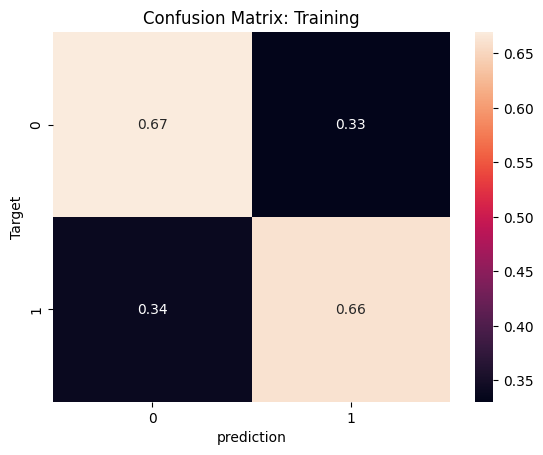

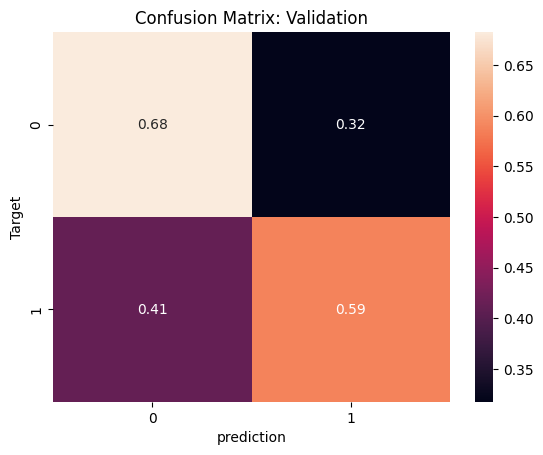

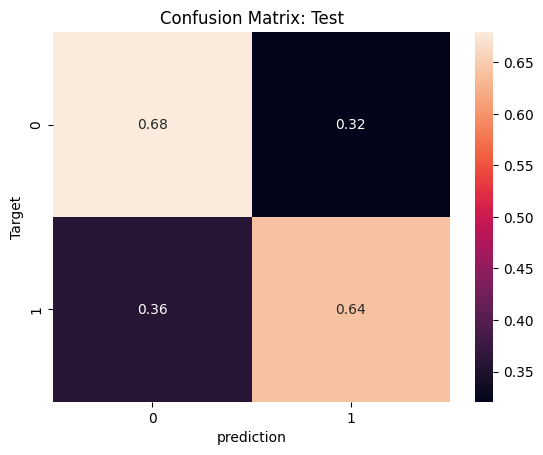

In [ ]:
def predict_and_plot(inputs,targets,name=' '):
    pred = model.predict(inputs)
    accu = accuracy_score(targets, pred)
    print('Accuracy : {:.2f}%'.format(accu*100))
    cf = confusion_matrix(targets,pred,normalize='true')
    plt.figure()
    sns.heatmap(cf,annot=True)
    plt.xlabel('prediction')
    plt.ylabel('Target')
    plt.title('Confusion Matrix: {}'.format(name))

    return pred

train_pred  = predict_and_plot(train_in,train_tar,"Training")
val_pred = predict_and_plot(valid_in,valid_tar,"Validation")
test_pred = predict_and_plot(test_in,test_tar,"Test")

c = classification_report(test_tar,test_pred)
print(c)
print(" ROC_AUCCURACY_SCORE")
d  = roc_auc_score(test_tar,test_pred)
d


## Advanced Model: XGBoost Classifier

XGBoost was used to capture non-linear relationships and feature interactions.  
Class imbalance was handled using the `scale_pos_weight` parameter.


In [ ]:
model1 = XGBClassifier(
            scale_pos_weight = 5 ,
            n_estimators=100,
            learning_rate=0.1,
            max_depth=10,
            min_child_weight = 1,
            gamma = 0)
model1.fit(train_in,train_tar)
pred = model.predict_proba(test_in)[:,1]


Accuracy : 87.10%
Accuracy : 73.36%
Accuracy : 73.68%
              precision    recall  f1-score   support

           0       0.86      0.72      0.78       611
           1       0.59      0.77      0.67       320

    accuracy                           0.74       931
   macro avg       0.72      0.75      0.73       931
weighted avg       0.77      0.74      0.74       931

0.7451846358428804


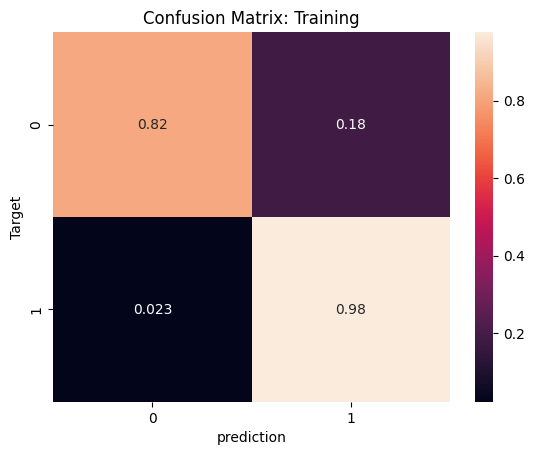

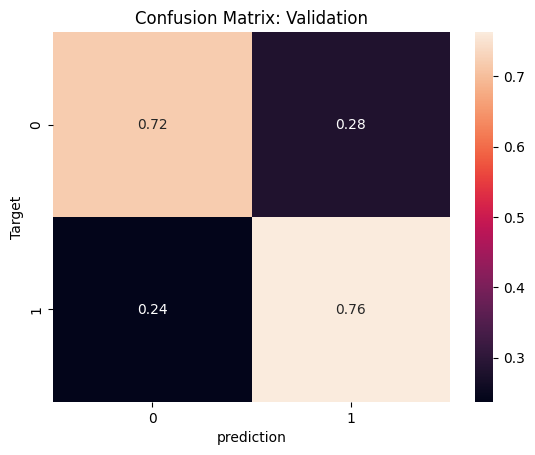

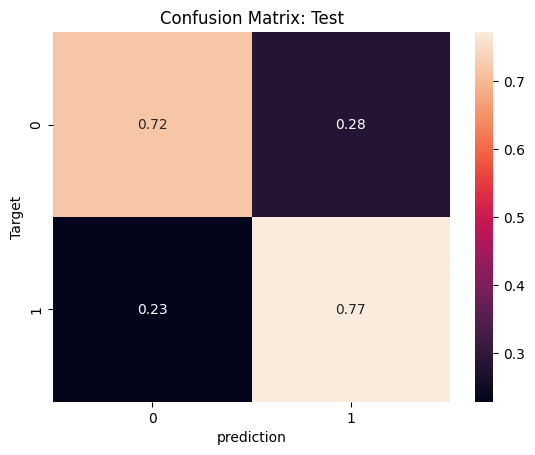

In [ ]:


def predict_and_plot(inputs,targets,name=' '):
    pred = model1.predict(inputs)
    accu = accuracy_score(targets, pred)
    print('Accuracy : {:.2f}%'.format(accu*100))
    cf = confusion_matrix(targets,pred,normalize='true')
    plt.figure()
    sns.heatmap(cf,annot=True)
    plt.xlabel('prediction')
    plt.ylabel('Target')
    plt.title('Confusion Matrix: {}'.format(name))

    return pred

train_pred  = predict_and_plot(train_in,train_tar,"Training")
val_pred = predict_and_plot(valid_in,valid_tar,"Validation")
test_pred = predict_and_plot(test_in,test_tar,"Test")

c = classification_report(test_tar,test_pred)
print(c)
d  = roc_auc_score(test_tar,test_pred)
print(d)


## Hyperparameter Optimization

RandomizedSearchCV was used to tune XGBoost hyperparameters.  
Since missing an employee who is likely to leave is more costly, recall was used as the optimization metric.


In [ ]:
param_dist = {
    'n_estimators': [100, 200, 500, 1000],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
    'min_child_weight': [1, 3, 5, 7, 9],
    'gamma': [0.0, 0.1, 0.2, 0.3, 0.4],
    # Crucially, explore weights around your base ratio of 1.9, but allow higher values
    'scale_pos_weight': [1.0, 1.9, 2.5, 3.0, 4.0, 5.0, 8.0],
    'colsample_bytree': [0.5, 0.7, 0.9, 1.0],
    'subsample': [0.5, 0.7, 0.9, 1.0]
}

# 2. Initialize the base model
xgb = XGBClassifier(objective='binary:logistic',  eval_metric='logloss')

# 3. Setup the Randomized Search
# KEY STEP: We set 'scoring="recall"' so it finds the model that maximizes recall for Class 1
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=50,          # Number of parameter combinations to try (adjust based on time)
    scoring='recall',   # OPTIMIZE FOR RECALL (Class 1)
    cv=5,               # 5-fold cross-validation
    verbose=1,          # Prints progress updates
    random_state=42,
    n_jobs=-1           # Use all available CPU cores
)

# 4. Run the search
random_search.fit(train_in, train_tar)

# 5. Output the best result
print(f"Best score achieved (Recall): {random_search.best_score_:.4f}")
print(f"Best parameters found: {random_search.best_params_}")

# Use this optimized model moving forward
best_model = random_search.best_estimator_


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best score achieved (Recall): 0.9187
Best parameters found: {'subsample': 0.5, 'scale_pos_weight': 8.0, 'n_estimators': 100, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.4, 'colsample_bytree': 0.9}


The model was optimized using RandomizedSearchCV with recall as the scoring metric, since missing an employee who is likely to leave is more costly than a false positive.


Accuracy : 60.62%
Accuracy : 58.00%
Accuracy : 61.12%
              precision    recall  f1-score   support

           0       0.92      0.45      0.60       611
           1       0.47      0.93      0.62       320

    accuracy                           0.61       931
   macro avg       0.69      0.69      0.61       931
weighted avg       0.76      0.61      0.61       931

0.685904255319149


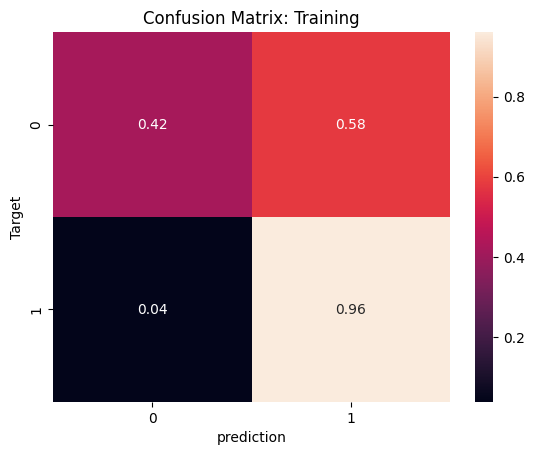

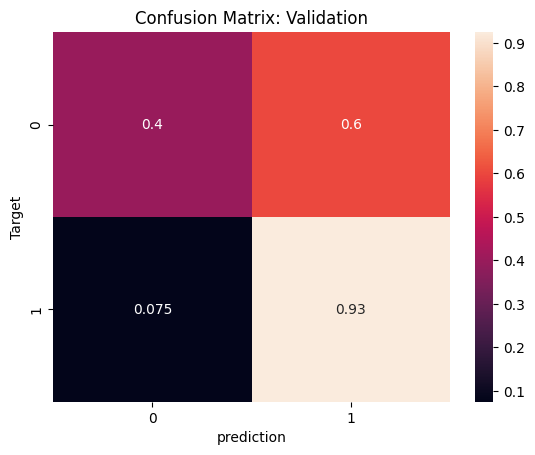

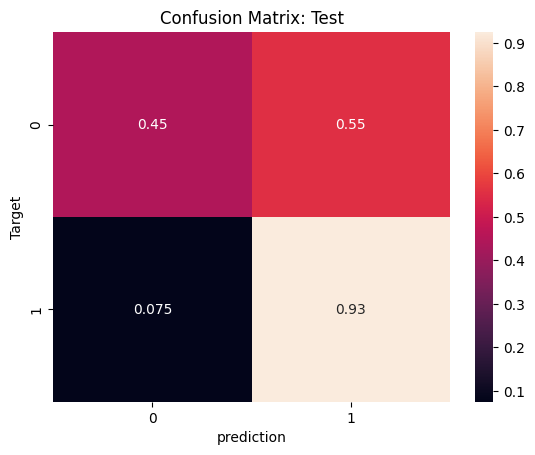

In [ ]:

def predict_and_plot(inputs,targets,name=' '):
    pred = best_model.predict(inputs)
    accu = accuracy_score(targets, pred)
    print('Accuracy : {:.2f}%'.format(accu*100))
    cf = confusion_matrix(targets,pred,normalize='true')
    plt.figure()
    sns.heatmap(cf,annot=True)
    plt.xlabel('prediction')
    plt.ylabel('Target')
    plt.title('Confusion Matrix: {}'.format(name))

    return pred

train_pred  = predict_and_plot(train_in,train_tar,"Training")
val_pred = predict_and_plot(valid_in,valid_tar,"Validation")
test_pred = predict_and_plot(test_in,test_tar,"Test")

c = classification_report(test_tar,test_pred)
print(c)
d  = roc_auc_score(test_tar,test_pred)
print(d)


## Probability Calibration

To make predicted probabilities more reliable for business decisions, isotonic calibration was applied using CalibratedClassifierCV.
Model calibration quality was evaluated using the Brier score.


In [ ]:
frozen_model = FrozenEstimator(best_model)

calibrator = CalibratedClassifierCV(
    frozen_model,
    method='isotonic',
    cv=5
)

calibrator.fit(train_in, train_tar)

calibrated_points = calibrator.predict_proba(test_in)[:, 1]

brier = brier_score_loss(test_tar, calibrated_points)
print(f"\n Brier score (lower is better): {brier:.4f} ")

priority_list = test_in[calibrated_points > 0.70]
print(f"\n Number of high-priority employees (>70% risk): {len(priority_list)}")



 Brier score (lower is better): 0.1167 

 Number of high-priority employees (>70% risk): 200


Probability calibration improves the reliability of predicted risk scores, making them more suitable for business decision-making.


## Business Use Case: High-Risk Employee Identification

Employees with predicted attrition probability greater than 70% are flagged as high-risk and prioritized for HR intervention.


In [ ]:
priority_list.head()
len(priority_list)


200

## Final Model and Deployment Artifacts

The final trained model and preprocessing objects are saved as:
- imputer.pkl  
- count_encoder.pkl  
- scaler.pkl  
- target_encoder.pkl  
- xgb_final_model.pkl  
- calibrator.pkl  

These artifacts are used by a separate driver script to perform batch predictions on new Excel inputs.
